<a href="https://colab.research.google.com/github/Blevins05/data-ai-summer2026/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Aprendizaje no supervisado aplicado a un Dataset de partidos de LaLiga 2019-2025

En este notebook, voy a repasar el aprendizaje automático no supervisado, aplicado a un dataset de partidos de LaLiga, para ver que equipos tienen un estilo de juego mas similar, y agruparlos por sus características de juego.

Empiezo cargando mi dataset como siempre:

In [26]:
import pandas as pd
df = pd.read_csv('matches_laliga.csv')

In [27]:
df.iloc[0:8]

,Unnamed: 0,date,time,comp,round,day,venue,result,gf,ga,...,match report,notes,sh,sot,dist,fk,pk,pkatt,season,team
0,0,2025-08-16,19:30,La Liga,Matchweek 1,Sat,Away,W,3.0,0.0,...,Match Report,NaN,24.0,8.0,18.9,1.0,0,0,2025,Barcelona
1,1,2025-08-23,21:30,La Liga,Matchweek 2,Sat,Away,W,3.0,2.0,...,Match Report,NaN,26.0,10.0,17.0,1.0,0,0,2025,Barcelona
2,2,2025-08-31,21:30,La Liga,Matchweek 3,Sun,Away,D,1.0,1.0,...,Match Report,NaN,11.0,2.0,20.3,0.0,1,1,2025,Barcelona
3,3,2025-09-14,21:00,La Liga,Matchweek 4,Sun,Home,W,6.0,0.0,...,Match Report,NaN,24.0,10.0,18.4,0.0,0,0,2025,Barcelona
4,5,2025-09-21,21:00,La Liga,Matchweek 5,Sun,Home,W,3.0,0.0,...,Match Report,NaN,16.0,7.0,18.2,2.0,0,0,2025,Barcelona
5,6,2025-09-25,21:30,La Liga,Matchweek 6,Thu,Away,W,3.0,1.0,...,Match Report,NaN,22.0,10.0,16.5,1.0,0,0,2025,Barcelona
6,7,2025-09-28,18:30,La Liga,Matchweek 7,Sun,Home,W,2.0,1.0,...,Match Report,NaN,22.0,9.0,17.5,1.0,0,0,2025,Barcelona
7,0,2025-08-19,21:00,La Liga,Matchweek 1,Tue,Home,W,1.0,0.0,...,Match Report,NaN,17.0,4.0,20.7,0.0,1,1,2025,Real Madrid


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4700 non-null   int64  
 1   date           4700 non-null   object 
 2   time           4700 non-null   object 
 3   comp           4700 non-null   object 
 4   round          4700 non-null   object 
 5   day            4700 non-null   object 
 6   venue          4700 non-null   object 
 7   result         4700 non-null   object 
 8   gf             4700 non-null   float64
 9   ga             4700 non-null   float64
 10  opponent       4700 non-null   object 
 11  xg             4700 non-null   float64
 12  xga            4700 non-null   float64
 13  poss           4700 non-null   float64
 14  attendance     3724 non-null   float64
 15  captain        4700 non-null   object 
 16  formation      4700 non-null   object 
 17  opp formation  4700 non-null   object 
 18  referee 

Igual que antes, hay columnas que no rentan nada meterlas para el clustering, es mala práctica, datos irrelevantes en este caso y además `sklearn` no acepta strings y demás.

In [29]:
cols = ['gf', 'ga', 'xg', 'xga', 'poss', 'sh', 'sot']
X = df[cols]

Estos son los descriptores que voy a utilizar y que me van a servir para descubrir estilos de juego similares dentro de los equipos que han pasado por LaLiga.

df es un DataFrame, pero nosotros estamos interesados en almacenar los valores del dataset como una lista de listas que es el formato esperado por la libreria sklearn. Para hacer esta conversion usamos el siguiente comando.

In [30]:
df_values = X.values

Ahora, voy a agrupar estas estadisticas por grupos, más bien por equipos. Si hiciese esto tal cual y aplicase clustering, estaría obteniendo partidos similares y no equipos.

In [31]:
df_teams = df.groupby('team')[cols].mean().reset_index()
df_teams.head()

,team,gf,ga,xg,xga,poss,sh,sot
0,Alaves,0.918782,1.431472,1.083756,1.331472,42.984772,9.812183,2.974619
1,Almeria,1.210526,1.842105,1.236842,1.639474,45.736842,12.065789,4.184211
2,Athletic Club,1.272340,0.991489,1.289787,1.047234,49.536170,11.978723,3.829787
3,Atletico Madrid,1.723404,0.893617,1.556170,0.948936,51.106383,12.425532,4.557447
4,Barcelona,2.174468,0.944681,1.972340,1.008936,65.659574,15.093617,5.629787


df es un DataFrame, pero nosotros estamos interesados en almacenar los valores del dataset como una lista de listas que es el formato esperado por la libreria sklearn. Para hacer esta conversion usamos el siguiente comando.

In [32]:
X_values = df_teams[cols].values

## K-means

Veámos como utilizar el algoritmo de [K-means de la librería sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans). Lo primero es cargar dicha funcionalidad. Todos los algoritmos de clustering disponibles en la librería sklearn se encuentran en el módulo [sklearn.cluster](https://scikit-learn.org/stable/modules/clustering.html). Además todos los algoritmos heredan de [BaseEstimator](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html), lo que nos permitirá intercambiar los algoritmos de manera sencilla.

In [33]:
from sklearn.cluster import KMeans

A continuación creamos un estimador usando dicha funcionalidad e indicándole el número de clusters a utilizar. Daros cuenta de que en el siguiente comando no indicamos el dataset, sino que simplemente iniciamos el algoritmo K-means, esto construye un objeto de la clase KMeans. Veremos que esta manera es la habitual para los algoritmos de clustering, y esto nos permitirá cambiar de algoritmo de manera sencilla.

In [34]:
estimator_kmeans = KMeans(n_clusters=3)

In [42]:
estimator_kmeans.fit(X_values)

KMeans(n_clusters=3)

Como se puede observar el comando anterior nos devuelve la instancia de la clase KMeans, para acceder a dicha información tenemos que usar el atributo labels_ de la clase KMeans.

In [43]:
estimator_kmeans.labels_

array([0, 0, 1, 1, 2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       2, 1, 1, 0, 0, 1], dtype=int32)

In [45]:
estimator_kmeans.labels_[[1, 7, 24]]

array([0, 0, 1], dtype=int32)

Otro de los atributos útiles que nos proporciona la clase KMeans es inertia_ que nos devuelve el valor de la función de coste.

In [46]:
estimator_kmeans.inertia_

208.70471133146165

Para continuar, voy a utilizar un código de la práctica 3 ya hecho. Me va a permitir aplicar el método de la silueta, de manera que voy a poder aplicar de manera óptima el KMeans, encontrando el número de cluster óptimo.

Recordamos que el método de la silueta es una simple fórmula que nos dice que tan cerca se encuentra una instancia de los vecinos de su cluster, y que tan alejada está del resto de vecinos.

In [48]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# La siguiente línea es un "magic command" de IPython/Colab para mostrar los gráficos directamente en el notebook
%matplotlib inline

def dibuja_siluetas(maxClusters, data):
    for n_clusters in range(2, maxClusters):
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(data) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, n_init="auto", random_state=10)
        cluster_labels = clusterer.fit_predict(data)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(data, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(data, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            data[:, 0], data[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()

Ahora llamamos a la función `dibuja_siluetas` con los datos `X_values` (que representan las estadísticas agregadas por equipo) para evaluar diferentes números de clusters. He establecido `maxClusters` en 10, lo que significa que evaluará de 2 a 9 clusters. Puedes ajustar este valor si lo necesitas.

For n_clusters = 2 The average silhouette_score is : 0.5408453495378773
For n_clusters = 3 The average silhouette_score is : 0.5121465499803222
For n_clusters = 4 The average silhouette_score is : 0.48383119367180666
For n_clusters = 5 The average silhouette_score is : 0.4513310380882562
For n_clusters = 6 The average silhouette_score is : 0.4336450759744774
For n_clusters = 7 The average silhouette_score is : 0.3886126332090307
For n_clusters = 8 The average silhouette_score is : 0.34154887153331953
For n_clusters = 9 The average silhouette_score is : 0.29492375753280575


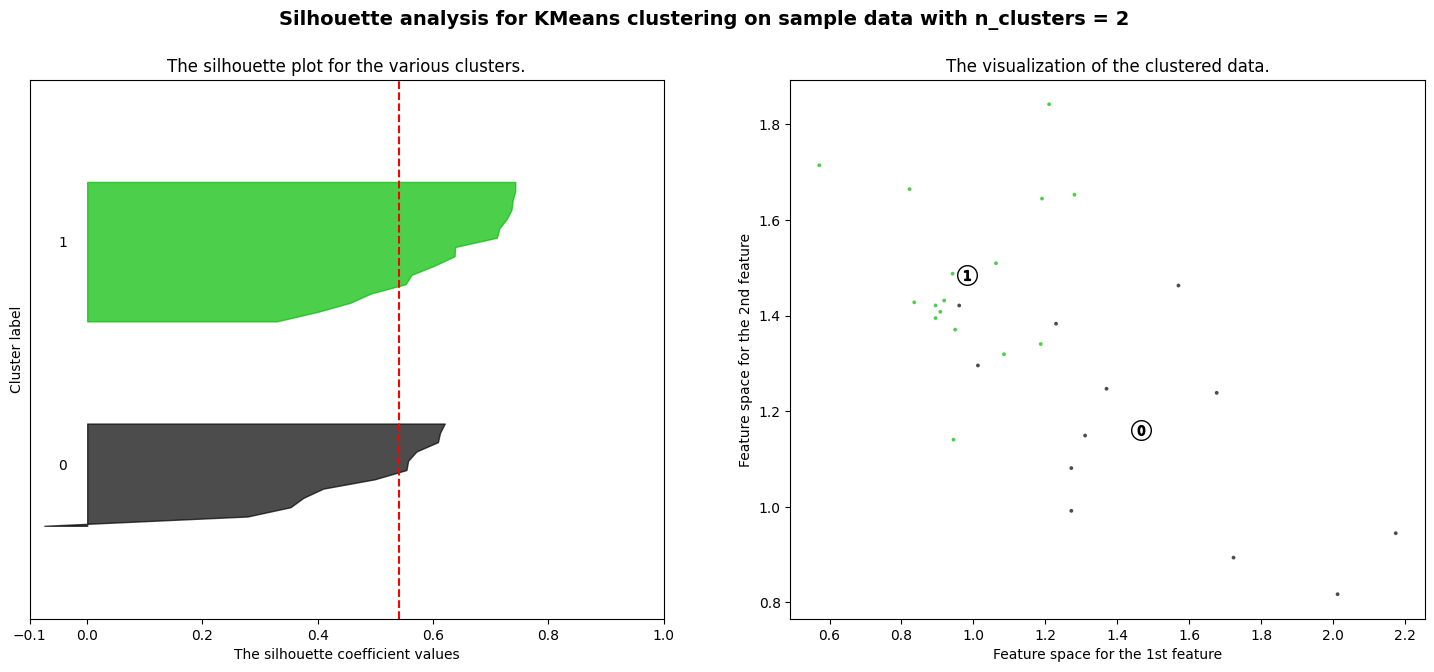

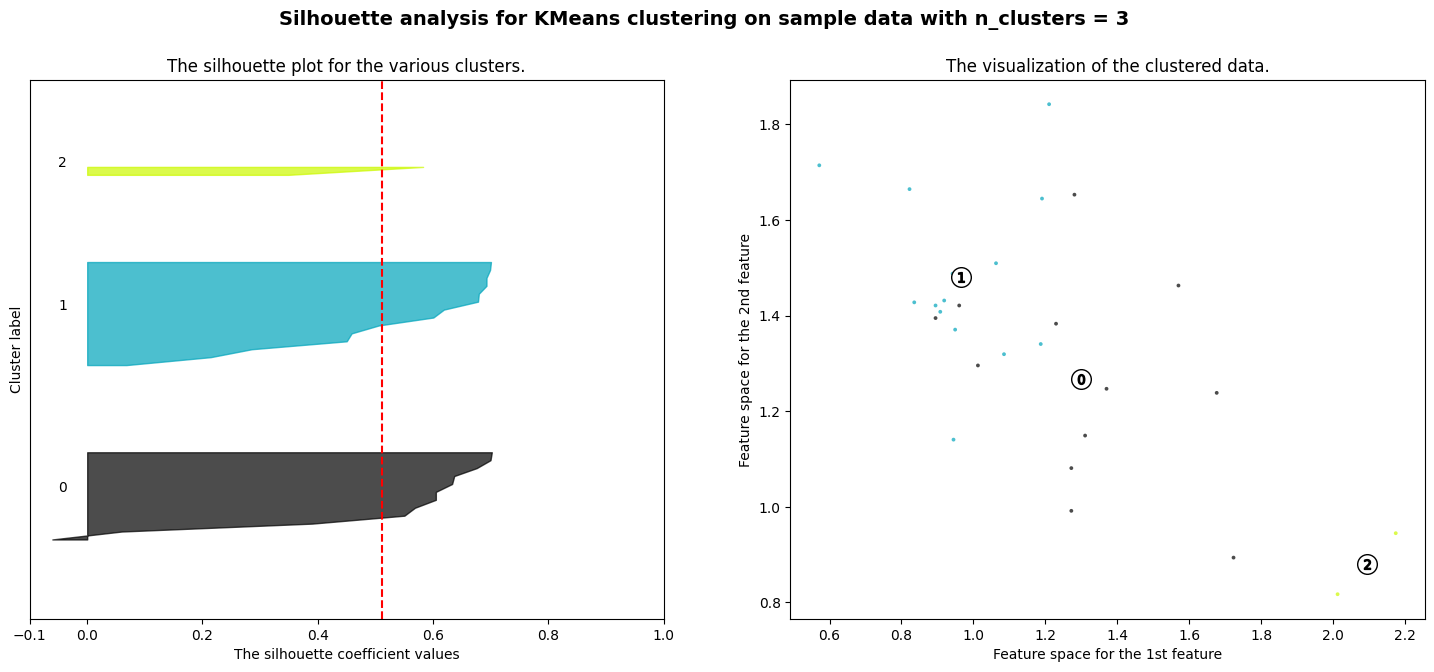

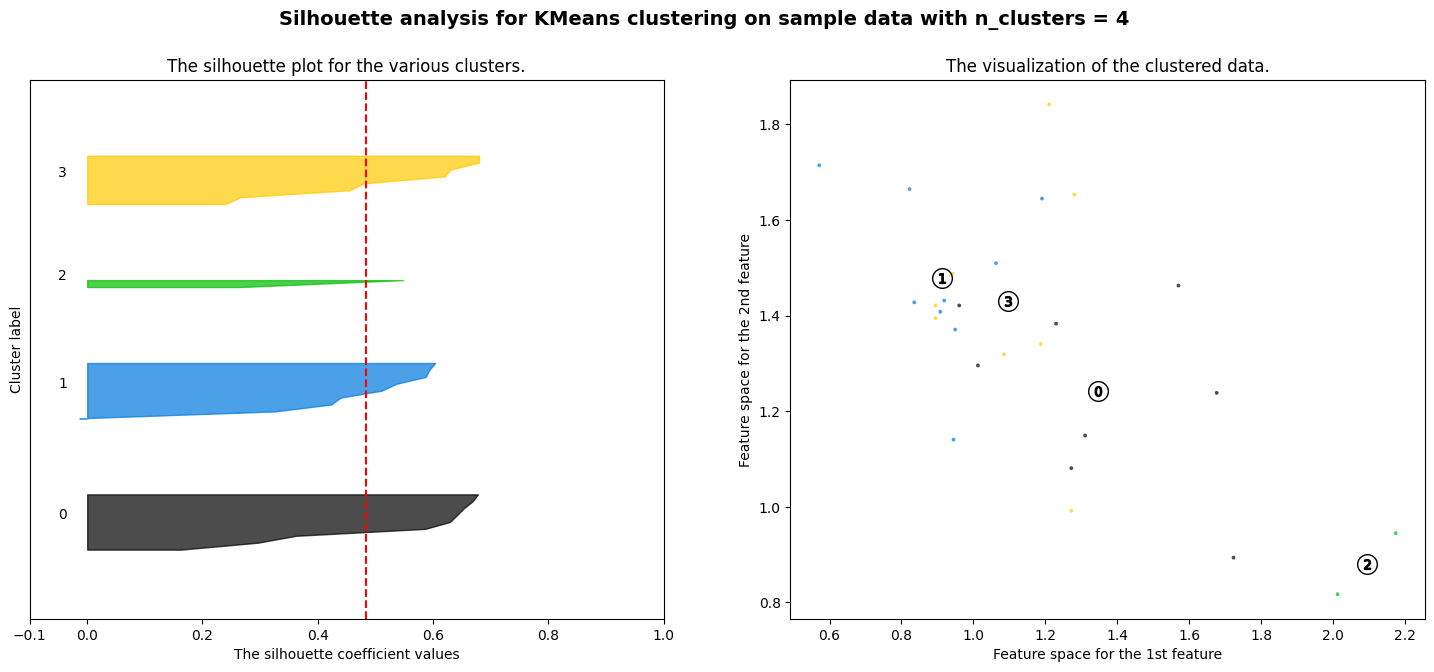

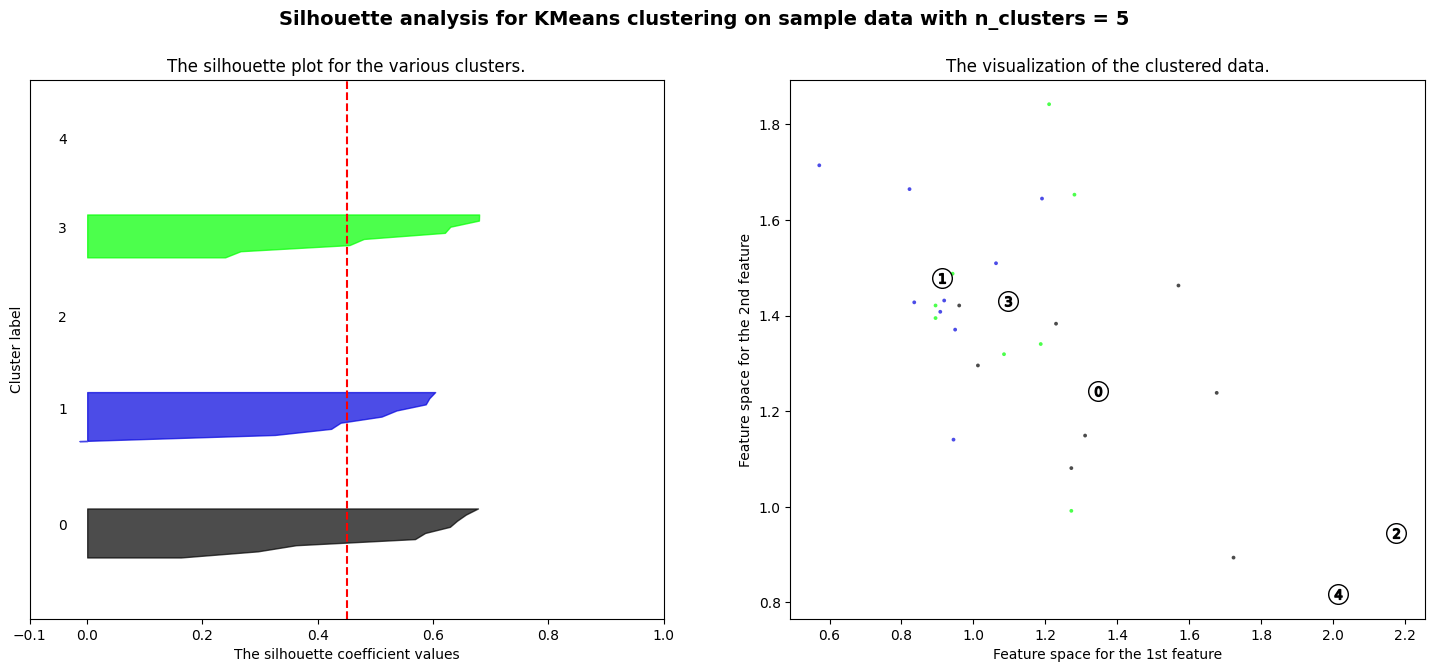

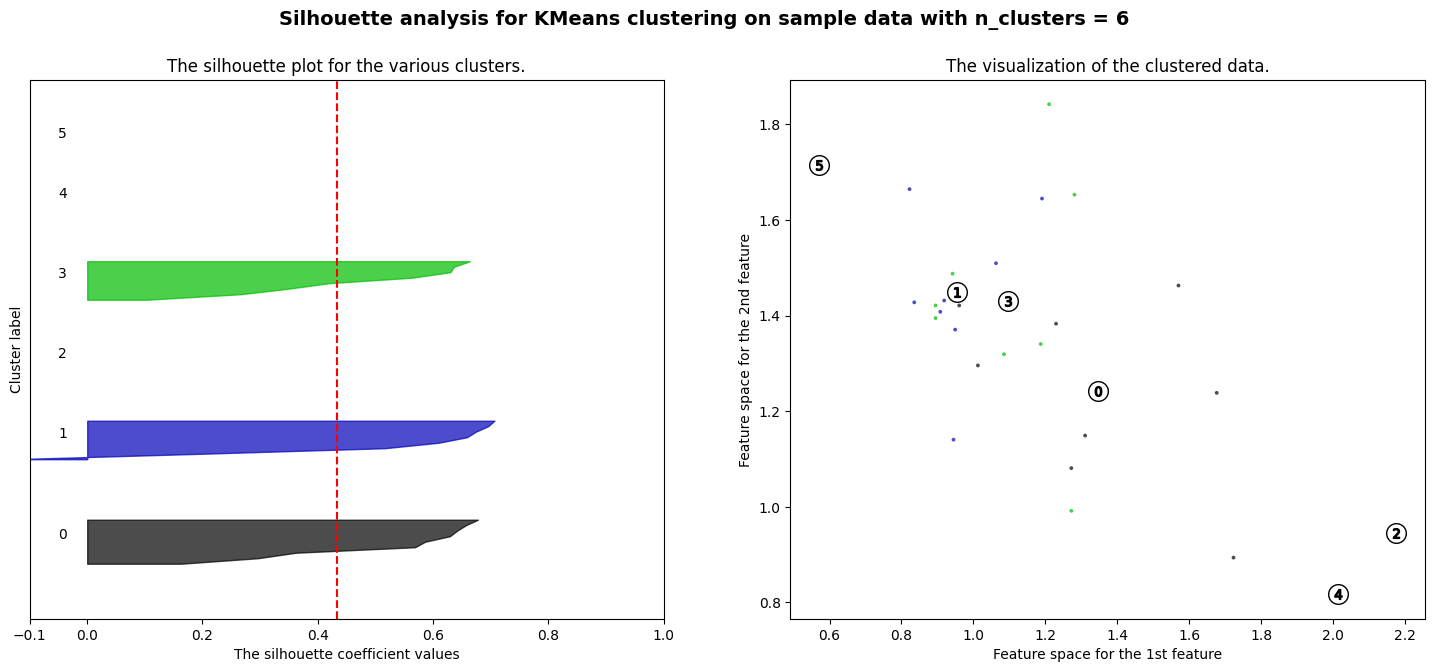

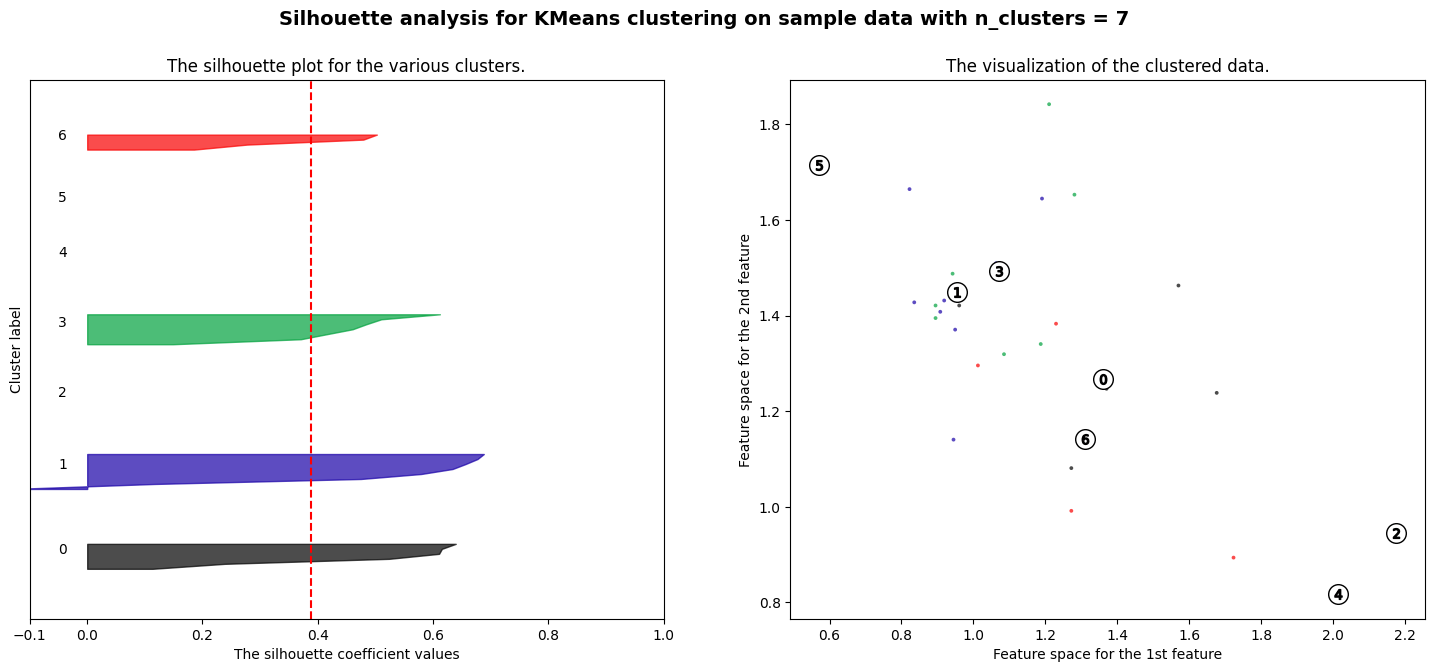

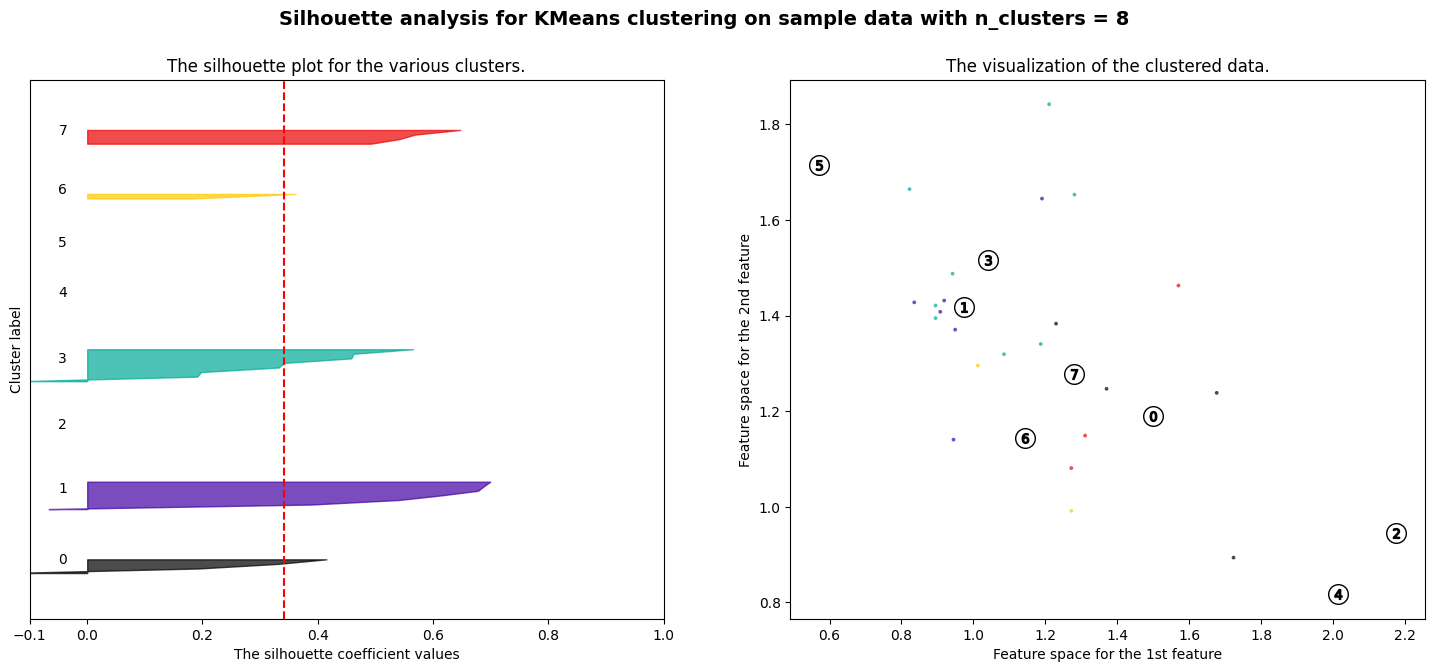

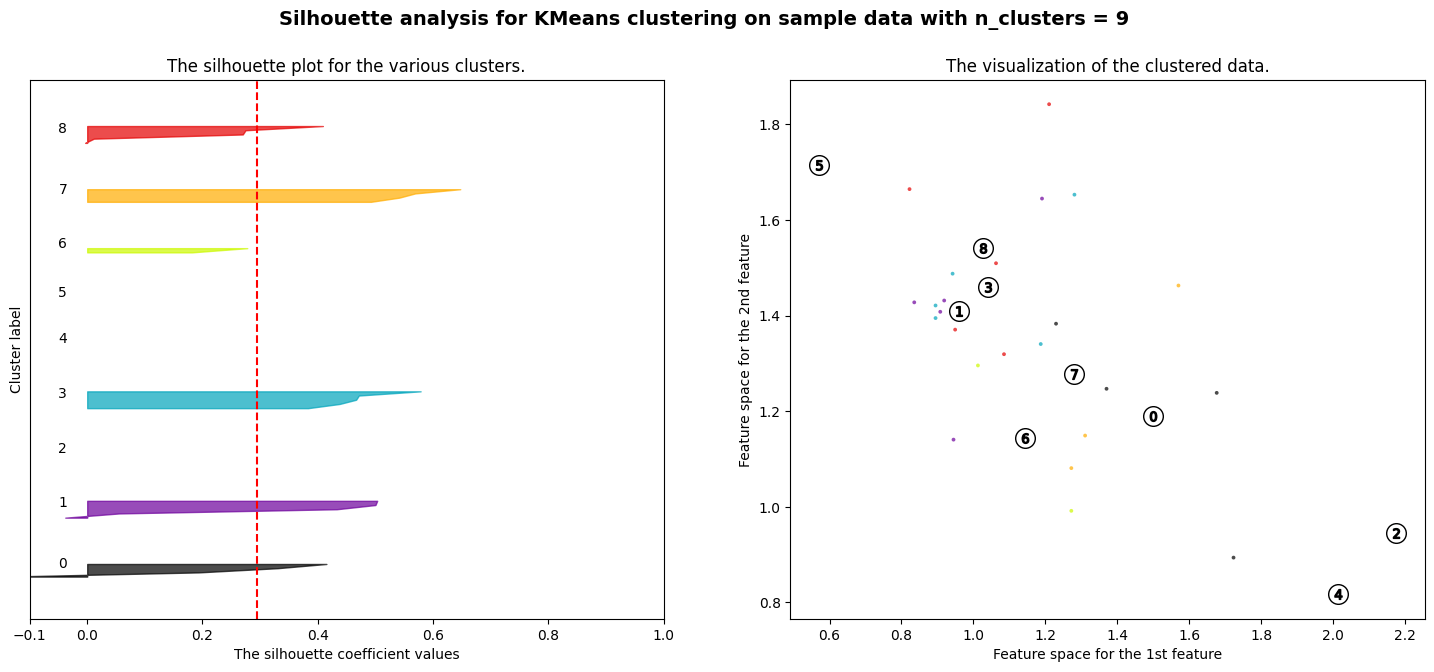

In [51]:
dibuja_siluetas(maxClusters=10, data=X_values)

Teniendo en cuenta los resultados, la estrategia mas óptima es dividir los equipos de LaLiga en 2 grandes grupos.

Voy a repetir el proceso anterior utilizando 2 clusters en vez de tres.

In [56]:
estimator_kmeans.n_clusters = 3

In [57]:
estimator_kmeans.fit(X_values)

KMeans(n_clusters=3)

In [58]:
estimator_kmeans.labels_

array([2, 2, 0, 0, 1, 2, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 2, 2, 2, 0, 0,
       1, 0, 0, 2, 2, 0], dtype=int32)

In [68]:
df_teams['cluster_km'] = estimator_kmeans.labels_
df_teams[['team', 'cluster_km']].sort_values('cluster_km')

,team,cluster_km
3,Atletico Madrid,0
2,Athletic Club,0
6,Celta Vigo,0
11,Girona,0
13,Huesca,0
14,Las Palmas,0
23,Real Sociedad,0
16,Levante,0
20,Rayo Vallecano,0
21,Real Betis,0


Aunque lo óptimo es utilizar 2 clústers basándonos en el método de la silueta, realmente prefiero 3 porque se puede ver claramente que Barcelona y Real Madrid tienen un estilo de juego claramente distinto y superior al del resto de equipos de LaLiga.

## Mean shift

Veámos ahora como utilizar el algoritmo de [Mean Shift](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html#sklearn.cluster.MeanShift). De nuevo, lo primero es cargar dicha funcionalidad.

In [62]:
from sklearn.cluster import MeanShift

Al igual que antes, creamos una instancia del algoritmo y probamos.

In [63]:
estimator_ms = MeanShift()

In [64]:
estimator_ms.fit(X_values)

MeanShift()

In [65]:
estimator_ms.labels_

array([0, 0, 1, 1, 3, 2, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 2, 1, 1,
       4, 1, 1, 0, 0, 1])

Creamos una nueva columna en el dataset de equipos donde tengamos la clusterización de `MeanShift` hecha

In [67]:
df_teams['cluster_ms'] = estimator_ms.labels_

In [70]:
df_teams[['team', 'cluster_ms']].sort_values(by='cluster_ms')

,team,cluster_ms
0,Alaves,0
1,Almeria,0
9,Espanyol,0
15,Leganes,0
12,Granada,0
10,Getafe,0
8,Elche,0
17,Mallorca,0
25,Valencia,0
26,Valladolid,0


En este caso `MeanShift` nos divide los equipos en 4 grupos distintos, siendo Real Madrid y Barcelona integrantes únicos de su grupo.

## DBSCAN

Repetimos lo mismo para el algoritmo de clustering [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN).

In [96]:
from sklearn.cluster import DBSCAN

In [97]:
estimator_db = DBSCAN()
estimator_db.fit(X_values)
estimator_db.labels_

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [99]:
df_teams['cluster_db'] = estimator_db.labels_
df_teams[["team", "cluster_db"]].sort_values('cluster_db')

,team,cluster_db
0,Alaves,-1
1,Almeria,-1
2,Athletic Club,-1
3,Atletico Madrid,-1
4,Barcelona,-1
5,Cadiz,-1
6,Celta Vigo,-1
7,Eibar,-1
8,Elche,-1
9,Espanyol,-1


El algoritmo DBSCAN asignó todos los equipos al cluster `-1`, lo que significa que todos fueron clasificados como ruido. Esto ocurre cuando los parámetros `eps` (radio de vecindad) y `min_samples` (cantidad mínima de puntos en un vecindario) no son adecuados para la densidad de tus datos.

Para encontrar un valor `eps` apropiado, podemos usar el método `NearestNeighbors` para calcular la distancia a los vecinos más cercanos para cada punto y luego graficar estas distancias de forma ordenada. El `min_samples` a menudo se elige como 2 veces la dimensionalidad de los datos, o un valor entre 3 y 5.

En tu caso, `cols` tiene 7 características, por lo que un `min_samples` de 14 podría ser un buen punto de partida (2 * 7 = 14). Ahora, vamos a calcular las distancias para `eps`.

Se usará k = 14 para NearestNeighbors.


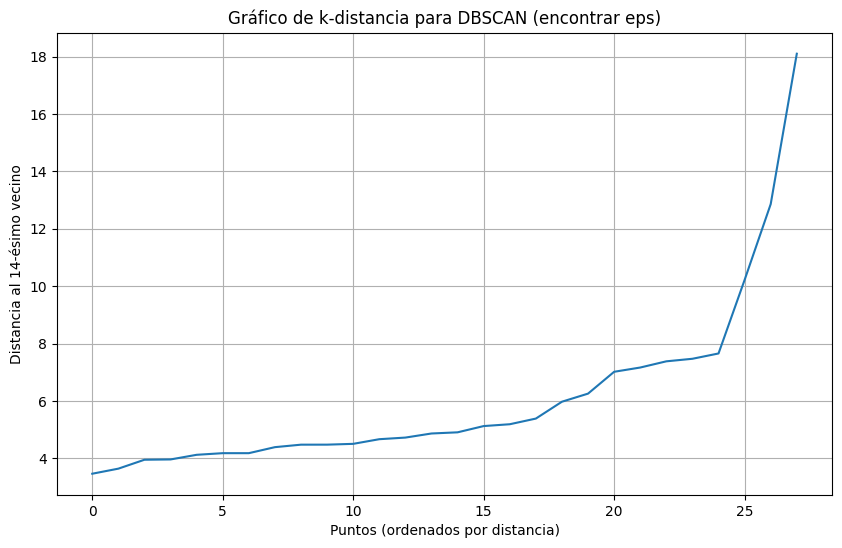

In [100]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Definimos k como min_samples. Un valor común es 2 * dimensionalidad de los datos.
k = 2 * X_values.shape[1] # Dimensionalidad es el número de columnas/características
print(f"Se usará k = {k} para NearestNeighbors.")

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_values)

distances, indices = neigh.kneighbors(X_values)

# Ordenamos las distancias (especialmente la k-ésima distancia) en orden ascendente
distances = np.sort(distances[:, k-1], axis=0)

# Graficamos las distancias
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel("Puntos (ordenados por distancia)")
plt.ylabel(f"Distancia al {k}-ésimo vecino")
plt.title("Gráfico de k-distancia para DBSCAN (encontrar eps)")
plt.grid(True)
plt.show()


En el gráfico anterior, busca el 'codo' o 'punto de inflexión'. Este punto sugiere un valor adecuado para `eps`. Un cambio abrupto en la curva indica una región donde los puntos se vuelven más dispersos.

Una vez que identifiques un `eps` adecuado del gráfico, puedes volver a ejecutar DBSCAN con ese valor y el `min_samples` que consideres apropiado (por ejemplo, `k` que usamos para el gráfico).

In [143]:
estimator_db.eps = 3.5


In [141]:
estimator_db.fit(X_values)

DBSCAN(eps=2.5)

In [142]:
df_teams['cluster_db'] = estimator_db.labels_
df_teams[["team", "cluster_db"]].sort_values('cluster_db')

,team,cluster_db
4,Barcelona,-1
19,Oviedo,-1
22,Real Madrid,-1
0,Alaves,0
3,Atletico Madrid,0
5,Cadiz,0
2,Athletic Club,0
1,Almeria,0
8,Elche,0
9,Espanyol,0
